**Dataset da IBM sobre RH**

Será feito um modelo de ML para prever a saída de funcionários e evitar saídas imprevistas para não prejudicar o desempenho dos times da empresa.

In [1]:
# Dataset da IBM sobre RH

# Inicialização

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 40)
pd.set_option('display.max_columns', None)

plt.style.use('ggplot')

!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.5 MB/s eta 0:00:00


**Carregar dataset**


In [4]:
url = 'https://raw.githubusercontent.com/Cesdata/HR_Analytics_Retention_Model/main/IBM-HR-Analytics.csv'
hr_data = pd.read_csv(url)

hr_data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [5]:
hr_data.shape

(1470, 35)

In [6]:
hr_data.nunique().sort_values()

,0
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


In [7]:
# Proporção de demissões

hr_data.Attrition.value_counts(1)

,proportion
Attrition,
No,0.838776
Yes,0.161224


In [8]:
hr_data["Attrition"] = hr_data["Attrition"].map({"Yes": 1, "No": 0})
#

**MODELAGEM DE MACHINE LEARNING**

In [9]:
# Bibliotecas necessárias

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder, CatBoostEncoder, WOEEncoder, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from lightgbm import LGBMClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

In [10]:
# Separação de features e Target

X = hr_data.drop('Attrition', axis=1)
y = hr_data['Attrition']

In [11]:
# Divisão de dados

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
from sklearn.utils.class_weight import compute_class_weight

# Calcula os pesos
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

#Dicionário de pesos
weights_dict = {class_label: weight for class_label, weight in zip(np.unique(y_train), class_weights)}

print(weights_dict)

{np.int64(0): np.float64(0.6012269938650306), np.int64(1): np.float64(2.9696969696969697)}


In [13]:
weights_dict

{np.int64(0): np.float64(0.6012269938650306),
 np.int64(1): np.float64(2.9696969696969697)}

In [14]:
# Filtro de não numéricos e numéricos

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

In [15]:
# Pré processamento

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
categorical_transformer = Pipeline(steps=[("encoder", TargetEncoder())])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ("select", SelectKBest(f_classif, k=10)),
                           ("classifier", LogisticRegression(class_weight=weights_dict))
])

pipeline.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 4 17] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education', 'EmployeeCount',
                                                   'EmployeeNumber',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorke...
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   TargetEncoder())]),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'Over18', 'OverTime'])])),
                ('select', SelectKBest()),
                ('classifier',
                 LogisticRegression(class_weight={np.int64(0): np.float64(0.6012269938650306),
                                                  np.int64(1): np.float64(2.9696969696969697)}))])

In [16]:
y_pred = pipeline.predict(X_test)

In [17]:
# Probabilidade de ser 1 ou 0 - dividido em 0.5 a princípio

pipeline.predict_proba(X_test)



array([[0.46621207, 0.53378793],
       [0.59012505, 0.40987495],
       [0.3596264 , 0.6403736 ],
       [0.57984344, 0.42015656],
       [0.60307657, 0.39692343],
       [0.5920373 , 0.4079627 ],
       [0.41454624, 0.58545376],
       [0.69713858, 0.30286142],
       [0.60021799, 0.39978201],
       [0.27509435, 0.72490565],
       [0.29893514, 0.70106486],
       [0.70514306, 0.29485694],
       [0.39977163, 0.60022837],
       [0.57801898, 0.42198102],
       [0.34780951, 0.65219049],
       [0.54969253, 0.45030747],
       [0.37502269, 0.62497731],
       [0.68578016, 0.31421984],
       [0.72099089, 0.27900911],
       [0.8863554 , 0.1136446 ],
       [0.40384952, 0.59615048],
       [0.76112764, 0.23887236],
       [0.60778061, 0.39221939],
       [0.47838757, 0.52161243],
       [0.51410553, 0.48589447],
       [0.88071897, 0.11928103],
       [0.27916654, 0.72083346],
       [0.61459889, 0.38540111],
       [0.3673426 , 0.6326574 ],
       [0.71039214, 0.28960786],
       [0.

In [18]:
# Eficácia do modelo

print(f"Precison: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")
print(f"F1: {f1_score(y_test, y_pred)}")
print(f"Acc: {accuracy_score(y_test, y_pred)}")

y_pred_proba = pipeline.predict_proba(X_test)
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba[:,1])}")

Precison: 0.19008264462809918
Recall: 0.5897435897435898
F1: 0.2875
Acc: 0.6122448979591837
ROC AUC: 0.6577174459527401


_ Precision: De todas as pessoas que o modelo disse que sairiam, acertou 19%.

_ Recall: De todos que realmente saíram, o modelo previu 61%.

In [19]:
# Teste de nota de corte

results = []

for thres in np.arange(0.05, 1, 0.05):

  y_pred = (pipeline.predict_proba(X_test)[:,1] > thres)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  acc = accuracy_score(y_test, y_pred)

  results.append([thres, precision, recall, f1, acc])

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

In [20]:
results_df = pd.DataFrame(results, columns=['thres', 'precision', 'recall', 'f1', 'acc'])
results_df

,thres,precision,recall,f1,acc
0,0.05,0.132653,1.000000,0.234234,0.132653
1,0.10,0.133562,1.000000,0.235650,0.139456
2,0.15,0.135714,0.974359,0.238245,0.173469
3,0.20,0.141791,0.974359,0.247557,0.214286
4,0.25,0.145669,0.948718,0.252560,0.255102
5,0.30,0.144737,0.846154,0.247191,0.316327
6,0.35,0.146226,0.794872,0.247012,0.357143
7,0.40,0.159574,0.769231,0.264317,0.431973
8,0.45,0.176471,0.692308,0.281250,0.530612
9,0.50,0.190083,0.589744,0.287500,0.612245


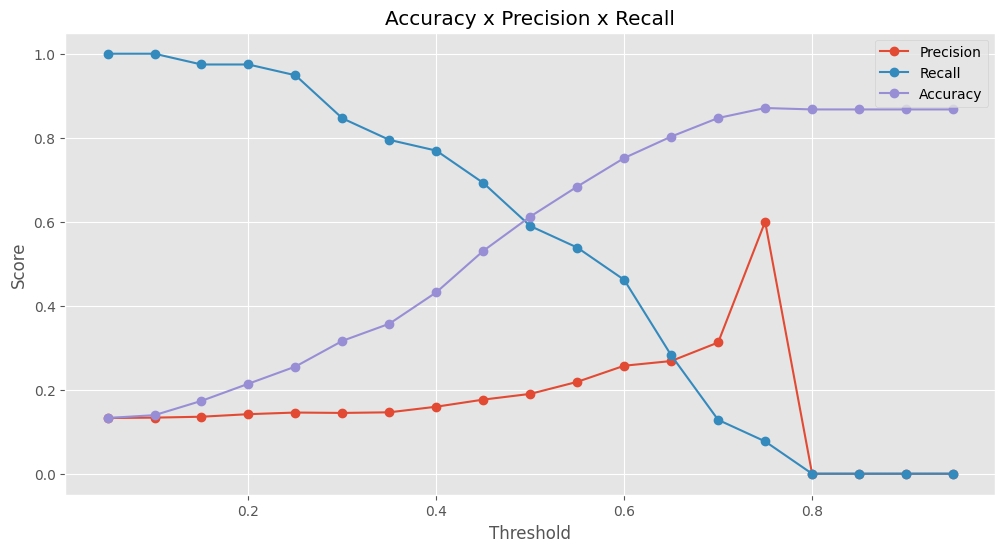

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(results_df["thres"], results_df["precision"], label = "Precision", marker = 'o')
plt.plot(results_df["thres"], results_df["recall"], label = "Recall", marker = 'o')
plt.plot(results_df["thres"], results_df["acc"], label = "Accuracy", marker = 'o')

plt.title("Accuracy x Precision x Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()



# **Análise de Trade-off e Viabilidade de Negócio**


Este projeto demonstra que a escolha do modelo de Machine Learning não se resume apenas à acurácia, mas sim à otimização do ROI (Retorno sobre Investimento). No contexto de retenção de talentos (HR Analytics), enfrentamos um trade-off clássico entre Precisão e Recall:

A Estratégia: O modelo identifica funcionários com alto risco de churn (demissão) para que a empresa possa intervir proativamente, por exemplo, oferecendo um upgrade no plano de saúde ou bônus de retenção.

A Simulação: Supondo que uma intervenção seja capaz de reter 60% dos talentos propensos a sair, o sucesso da estratégia depende do ajuste do threshold (limiar de decisão):

Um threshold mais baixo aumenta o Recall, capturando mais funcionários em risco, porém elevando o custo operacional ao oferecer benefícios para quem talvez não saísse (Falsos Positivos).

Um threshold mais alto foca na Precisão, economizando recursos ao intervir apenas em casos de alta certeza, mas correndo o risco de perder talentos valiosos que não foram mapeados pelo modelo (Falsos Negativos).

Conclusão Final: O estudo da curva de performance e dos diferentes limiares de decisão permite que a gestão financeira compare o Custo de Retenção (pagar o benefício para o grupo selecionado) versus o Custo de Substituição (processo seletivo, integração e perda de produtividade do cargo vago). O modelo final entrega uma ferramenta de apoio à decisão que visa minimizar o desperdício de capital enquanto maximiza a retenção do capital humano.